In [121]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"
import keras
import bayesflow as bf
import numpy as np
import matplotlib.pyplot as plt

# Simple example

## Simulator

In [122]:
def context(batch_size, n=None):
    if n is None:
        n = np.random.randint(10, 30)

    return dict(n=n)

def prior(mu=None, sigma=None):
    if mu is None:
        mu = np.random.normal(loc=0.0, scale=1.0)
    if sigma is None:
        sigma = np.random.gamma(shape=4.0, scale=0.1)

    return dict(mu=mu, sigma=sigma)

def likelihood(n, mu, sigma):
    y = np.random.normal(mu, sigma, size=n)

    return dict(y=y)

def summary(y):
    mean = np.mean(y)
    sd = np.std(y, ddof=1)
    
    return dict(mean=mean, sd=sd)

In [123]:
simulator = bf.make_simulator([prior, likelihood, summary], meta_fn=context)

### Prior predictives

In [124]:
data = simulator.sample(1000)

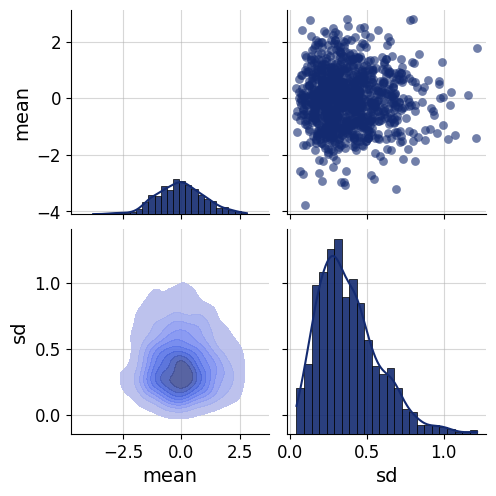

In [125]:
fig=bf.diagnostics.pairs_samples(data, variable_keys=["mean", "sd"])

## Approximator

In [126]:
adapter = (bf.Adapter()
    .broadcast("n", to="mean")
    .constrain("sigma", lower=0)
    .concatenate(["n", "mean", "sd"], into="inference_conditions")
    .concatenate(["mu", "sigma"], into="inference_variables")
    .drop("y")
    )

In [127]:
adapter(data)

{'inference_conditions': array([[ 2.70000000e+01,  8.84026571e-01,  6.43330670e-01],
        [ 2.70000000e+01,  6.11214735e-01,  5.87685135e-01],
        [ 2.70000000e+01, -2.14944590e-01,  4.30105022e-01],
        ...,
        [ 2.70000000e+01,  2.27104855e-02,  3.39280409e-01],
        [ 2.70000000e+01,  5.42159335e-01,  6.04980738e-01],
        [ 2.70000000e+01, -3.76516611e-01,  4.31694388e-01]],
       shape=(1000, 3)),
 'inference_variables': array([[ 0.82041857, -0.29566047],
        [ 0.68407393, -0.33051122],
        [-0.1504198 , -0.15487388],
        ...,
        [-0.01402133, -0.92880761],
        [ 0.42983745, -0.25140058],
        [-0.34155798, -0.5180014 ]], shape=(1000, 2))}

In [128]:
inference_network=bf.networks.CouplingFlow(transform="spline")

In [129]:
workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    inference_network=inference_network,
)

In [130]:
epochs=10
num_batches=100
batch_size=256

In [131]:
history = workflow.fit_online(
    epochs=epochs,
    num_batches=num_batches,
    batch_size=batch_size,
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - loss: 2.1430
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 1.5182
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 1.3402
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 1.0558
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.4857
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.1405
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: -0.0163
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: -0.1224
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: -0.1492
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: -0.1499


INFO:bayesflow:Training completed in 1.04 minutes.


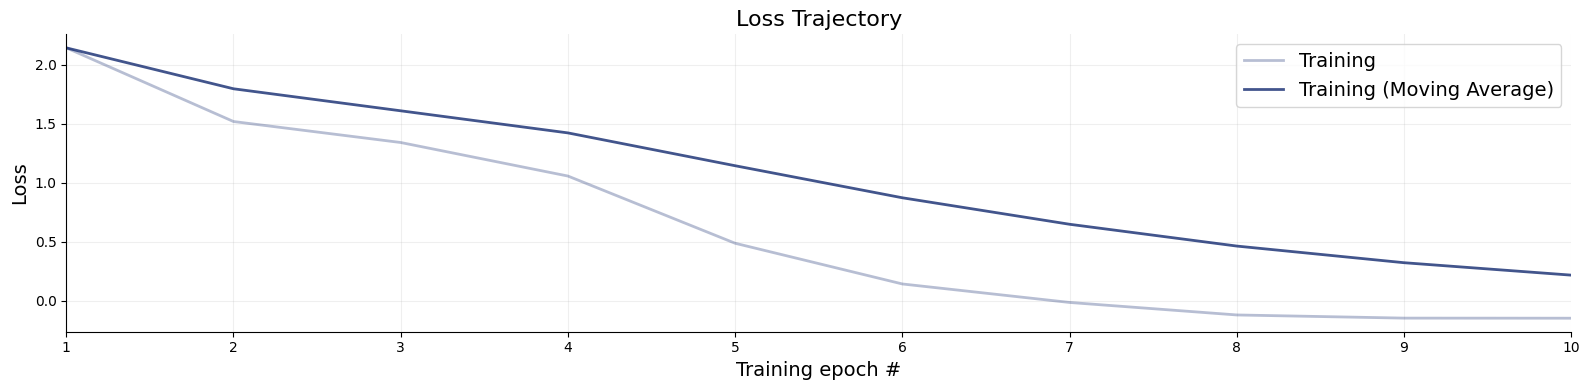

In [132]:
fig=bf.diagnostics.plots.loss(history)

## Validation

## Plot default diagnostics

Sampling: 100%|██████████| 1/1 [00:08<00:00,  8.14s/batch]


{'losses': <Figure size 1600x400 with 1 Axes>,
 'recovery': <Figure size 1000x500 with 2 Axes>,
 'calibration_ecdf': <Figure size 1000x500 with 2 Axes>,
 'coverage': <Figure size 1000x500 with 2 Axes>,
 'z_score_contraction': <Figure size 1000x500 with 2 Axes>}

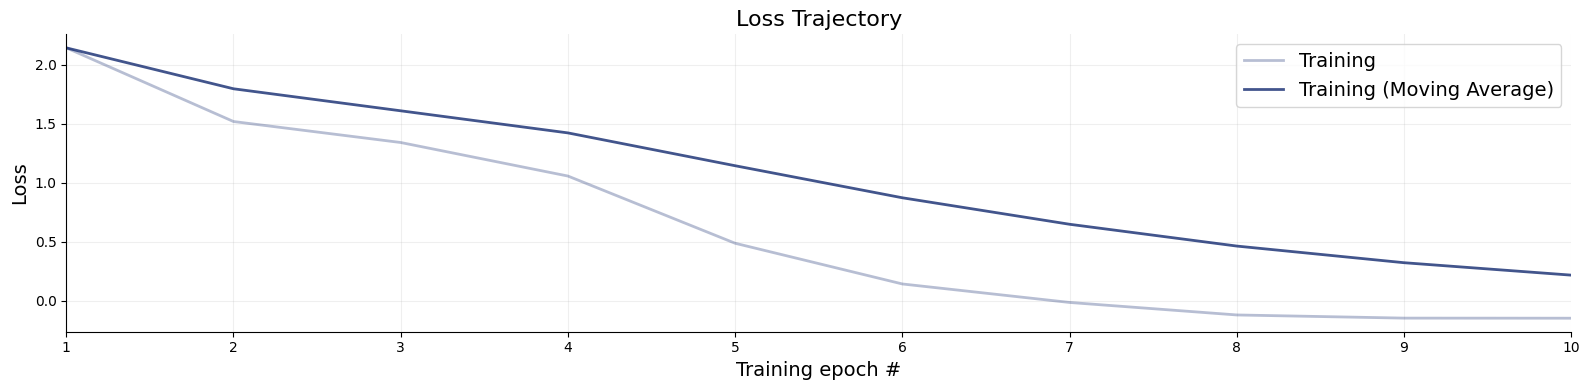

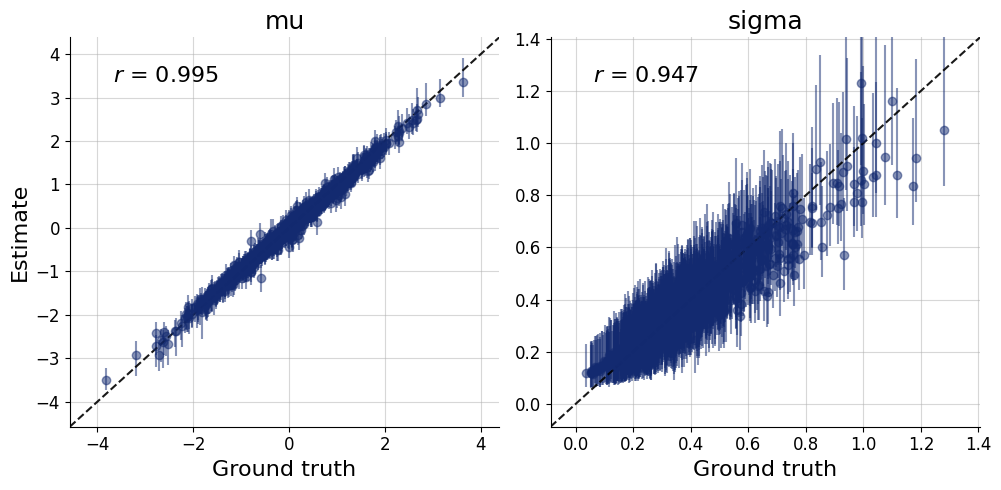

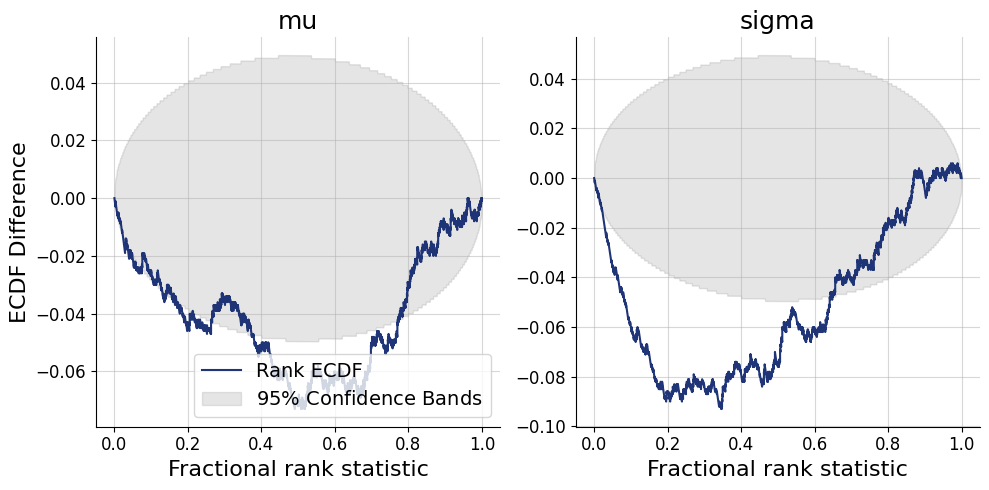

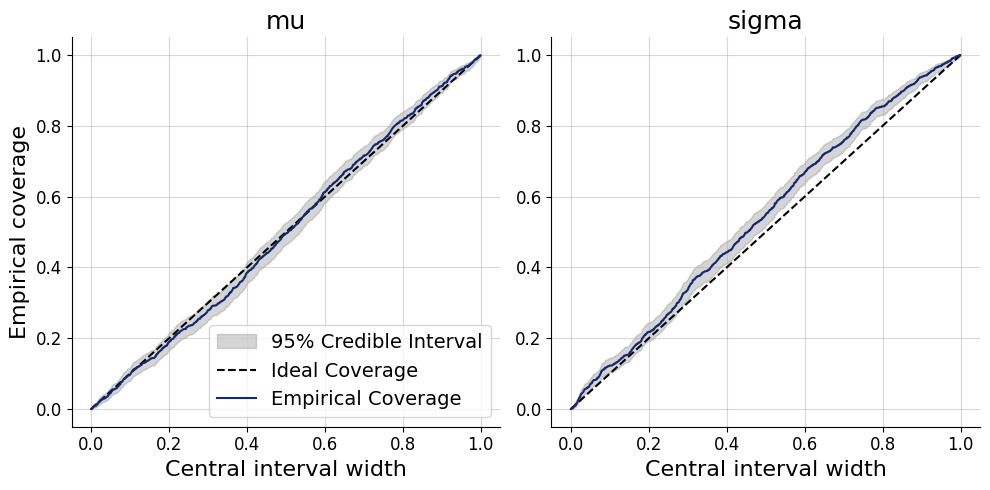

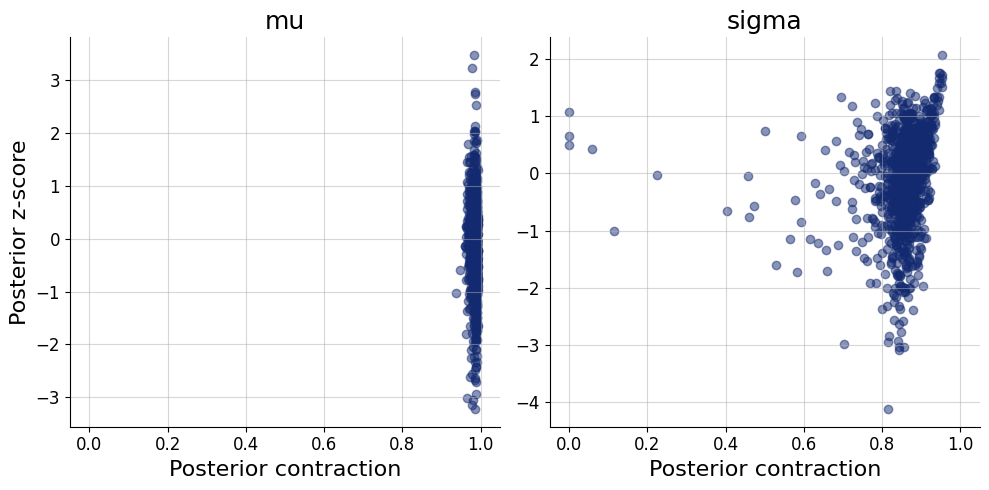

In [157]:
test_data = simulator.sample(1000, n=20)
workflow.plot_default_diagnostics(test_data)

### Run some diagnostics manually

In [158]:
prior = dict(mu=test_data["mu"], sigma=test_data["sigma"])
posterior = workflow.sample(num_samples=500, conditions=test_data)

Sampling: 100%|██████████| 1/1 [00:04<00:00,  4.25s/batch]
INFO:bayesflow:Sampling completed in 4.26 seconds.


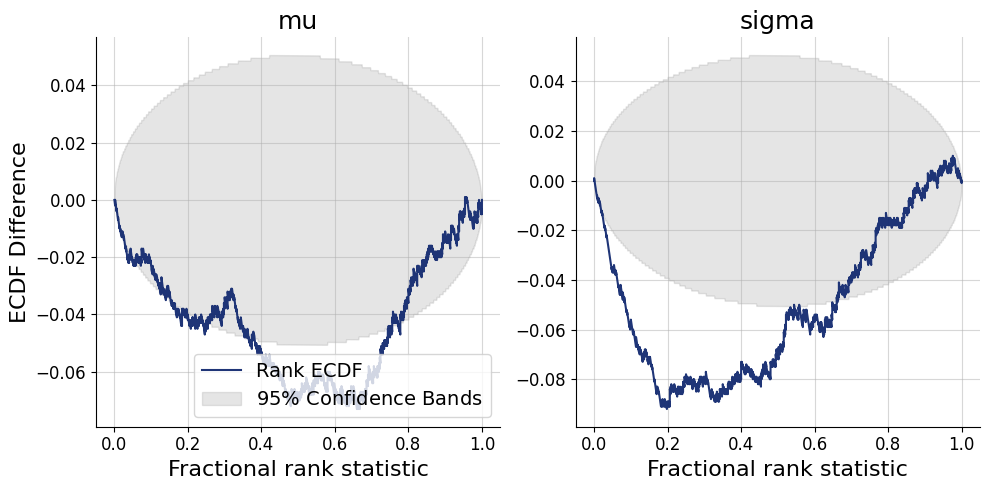

In [159]:
fig=bf.diagnostics.plots.calibration_ecdf(estimates=posterior, targets=prior)

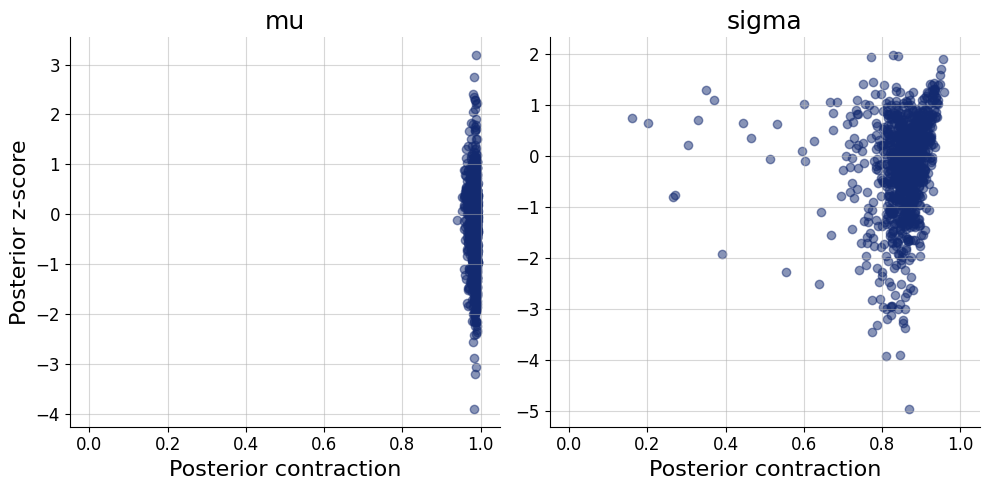

In [139]:
fig=bf.diagnostics.z_score_contraction(estimates=posterior, targets=prior)

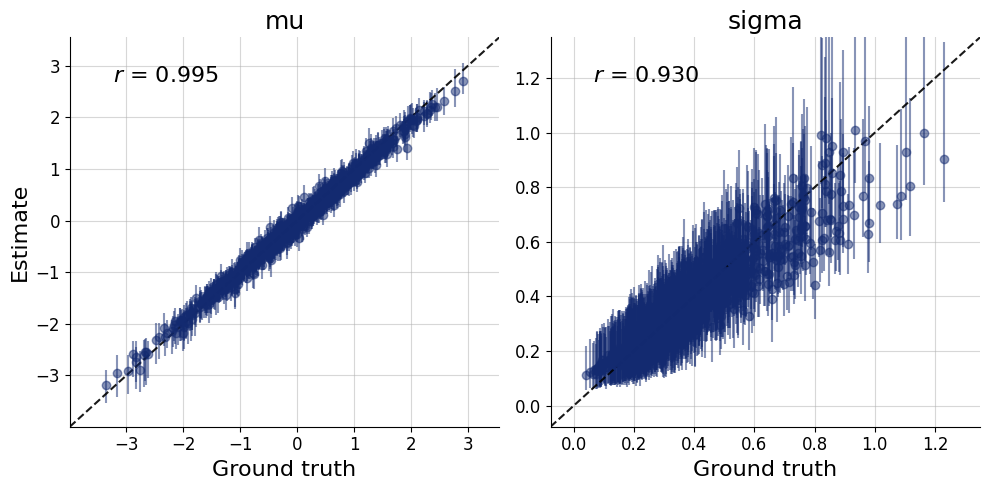

In [141]:
fig=bf.diagnostics.plots.recovery(estimates=posterior, targets=prior)

## Inference

In [153]:
inference_data = dict(n=20, mean=np.array([[-0.5]]), sd=np.array([[0.7]]))

In [154]:
posterior = workflow.sample(num_samples=1000, conditions=inference_data)

Sampling: 100%|██████████| 1/1 [00:00<00:00,  4.24batch/s]
INFO:bayesflow:Sampling completed in 0.24 seconds.


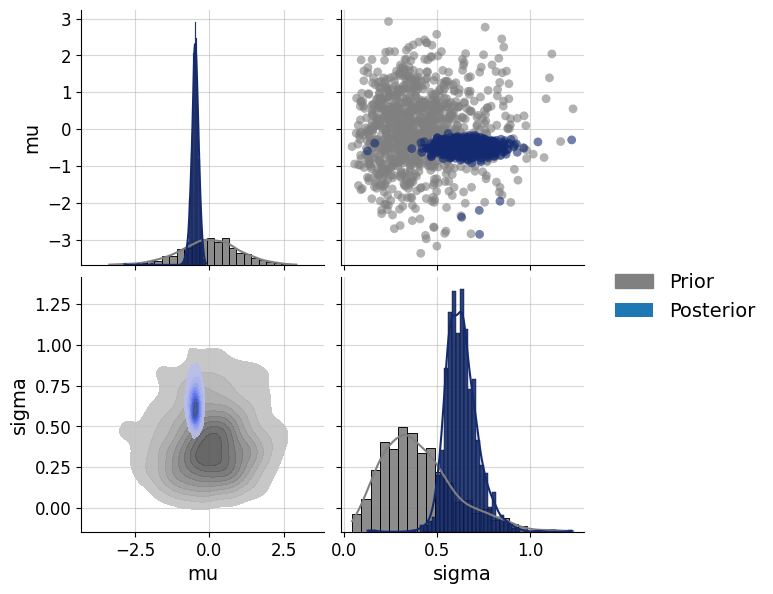

In [155]:
fig=bf.diagnostics.pairs_posterior(estimates=posterior, priors=prior)

# Using a summary network

## Define and run the workflow

In [161]:
adapter = (bf.Adapter()
    .broadcast("n", to="y")
    .as_set("y")
    .constrain("sigma", lower=0)
    .rename("n", "inference_conditions")
    .rename("y", "summary_variables")
    .concatenate(["mu", "sigma"], into="inference_variables")
    .drop(["mean", "sd"])
    )

In [162]:
workflow = bf.BasicWorkflow(
    inference_network=bf.networks.CouplingFlow(transform="spline"), 
    summary_network=bf.networks.DeepSet(),
    simulator=simulator,
    adapter=adapter,
)

In [163]:
history=workflow.fit_online(
    epochs=epochs, 
    num_batches_per_epoch=num_batches, 
    batch_size=batch_size
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 102ms/step - loss: 1.5904
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step - loss: 0.7003
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - loss: 0.4120
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - loss: 0.2265
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - loss: -0.0030 
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - loss: -0.1485
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - loss: -0.2134
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - loss: -0.3213
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - loss: -0.4353
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - loss: -0.3872


INFO:bayesflow:Training completed in 2.43 minutes.


## Validation

In [164]:
test_data = simulator.sample(1000, n=20)

Sampling: 100%|██████████| 1/1 [00:08<00:00,  8.73s/batch]


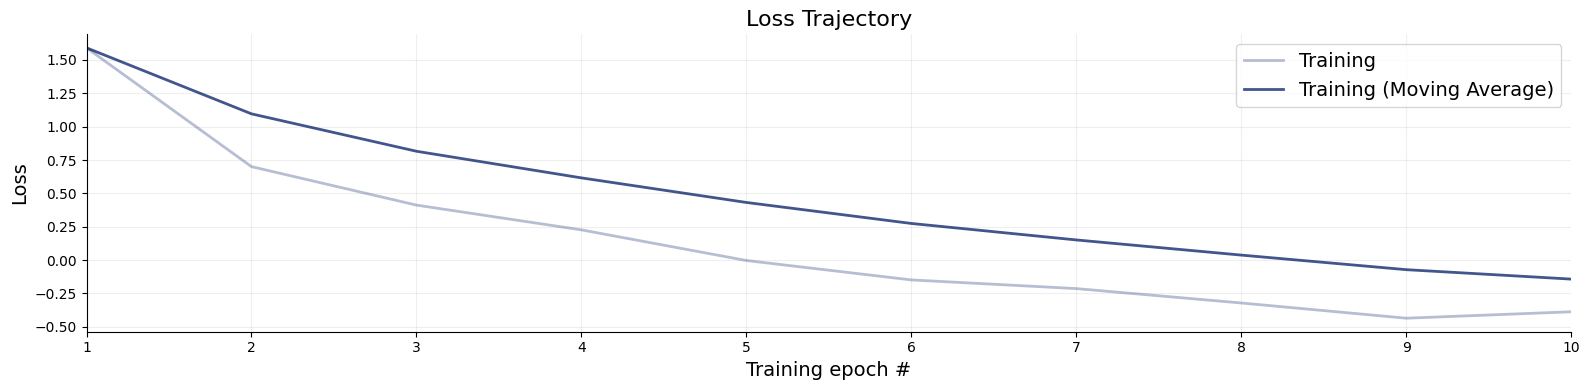

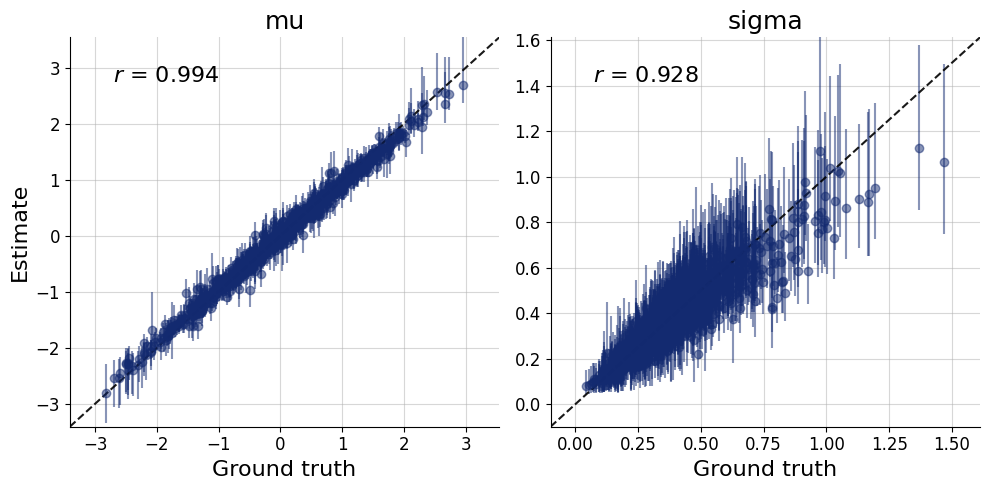

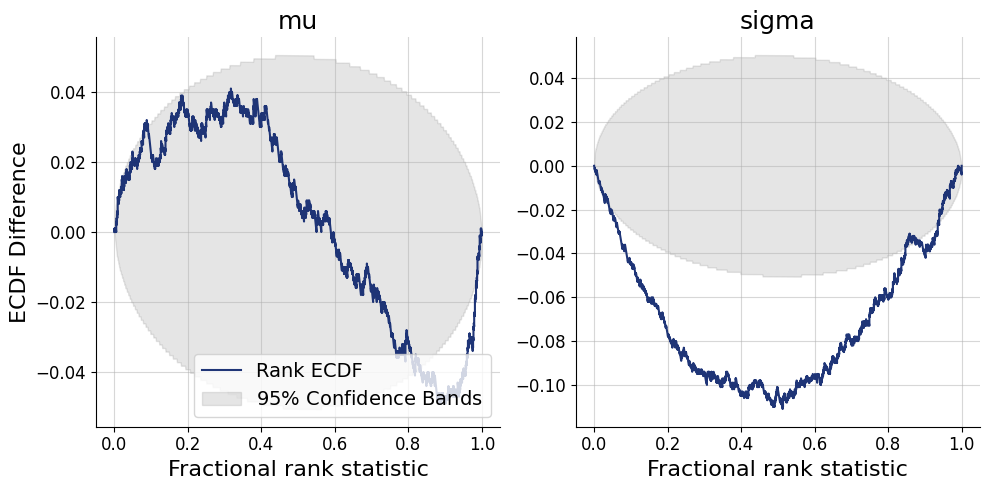

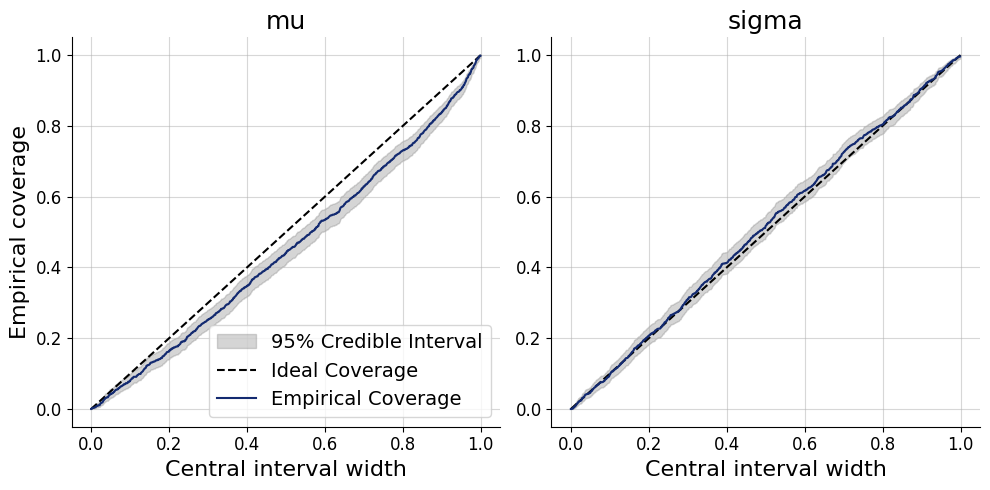

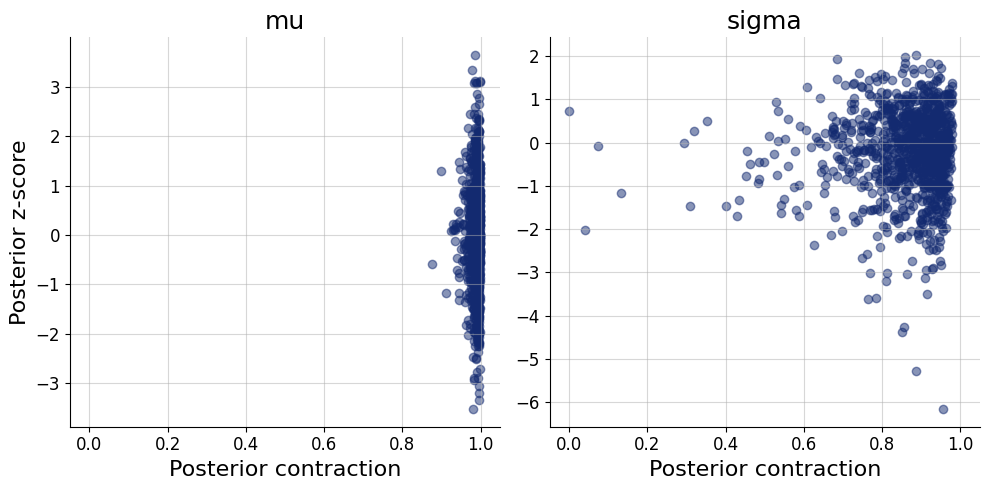

In [165]:
plots=workflow.plot_default_diagnostics(test_data=test_data)

## Inference

In [166]:
inference_data = dict(
    y = np.random.normal(loc=1, scale=0.6, size=(1, 20)),
    n = 20
)

In [167]:
num_samples=2_000

In [168]:
posterior=workflow.sample(num_samples=num_samples, conditions=inference_data)
posterior=keras.tree.map_structure(np.squeeze, posterior)

Sampling: 100%|██████████| 1/1 [00:00<00:00,  3.34batch/s]
INFO:bayesflow:Sampling completed in 0.34 seconds.


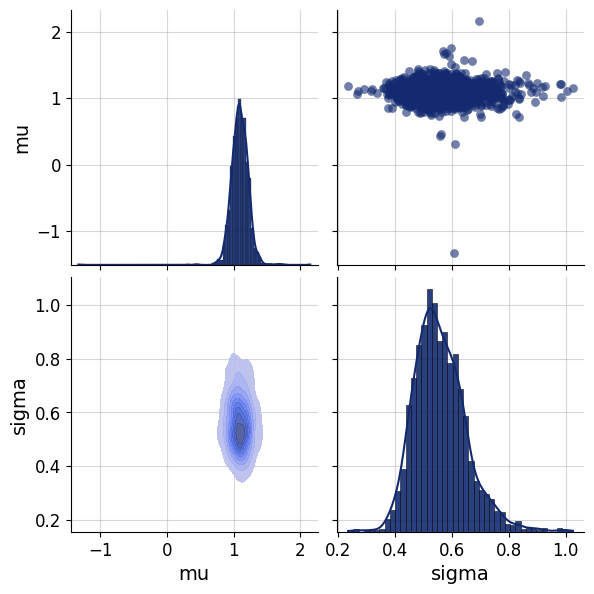

In [169]:
fig=bf.diagnostics.pairs_posterior(posterior)

### Posterior Predictive and Out-of-Distribution Checks

In [174]:
posterior_predictives = simulator.sample(num_samples, n=20, **posterior)

In [175]:
summary(inference_data["y"])

{'mean': np.float64(1.1848763121073937), 'sd': np.float64(0.6155753130834539)}

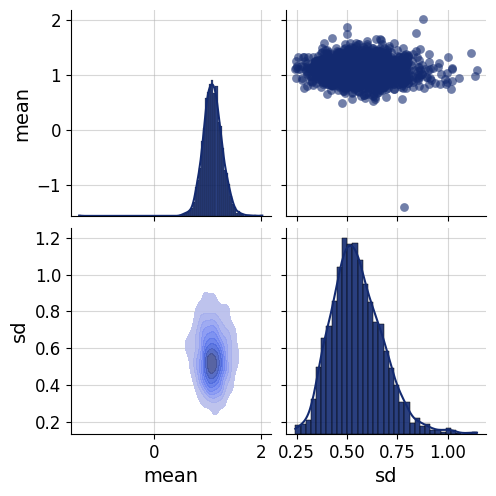

In [176]:
fig=bf.diagnostics.pairs_samples(posterior_predictives, variable_keys=["mean", "sd"])

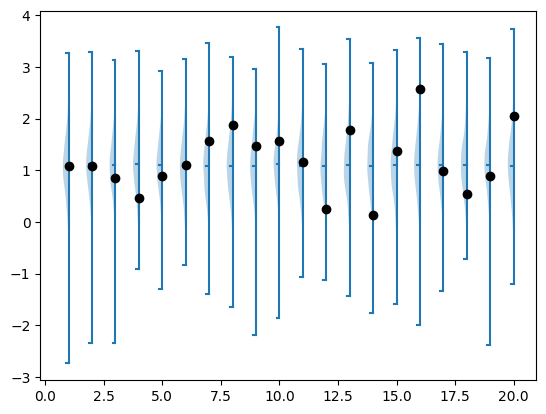

In [177]:
fig=plt.violinplot(posterior_predictives["y"], showmeans=True, side="low")
fig=plt.scatter(x=[i+1 for i in range(inference_data["n"])], y=inference_data["y"], c="black", zorder=100)

In [178]:
summaries_null=workflow.summary_network(workflow.simulate_adapted(1000)['summary_variables'])
summaries_ref=workflow.summary_network(workflow.simulate_adapted(500)['summary_variables'], training=False)

In [179]:
mmd_null = [
    bf.metrics.functional.maximum_mean_discrepancy(summaries_null, summaries_ref[i:i+1]).numpy() for i in range(500)
]

In [180]:
summaries_obs=workflow.summary_network(adapter(inference_data, strict=False)["summary_variables"])
mmd_obs=bf.metrics.functional.maximum_mean_discrepancy(summaries_null, summaries_obs)

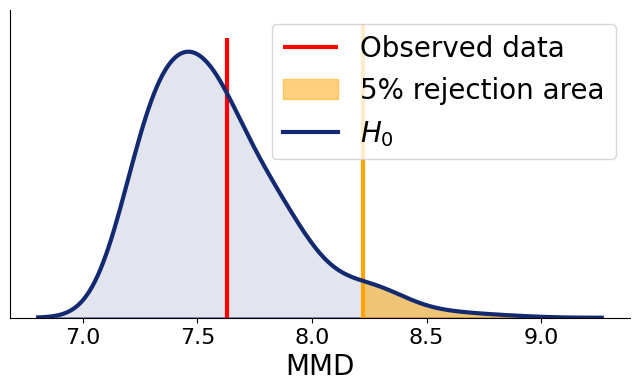

In [181]:
fig=bf.diagnostics.plots.mmd_hypothesis_test(mmd_null, mmd_obs)

# Further Tasks

1. Train a BayesFlow model that estimates the mean vector and a variance-covariance matrix of a 2D Gaussian.
2. Train a BayesFlow model that estimates parameter of any other distribution. You are free to choose which (some examples: Gamma, Negative binomial, Weibull,...)
3. The implementation of the normal model imposes one particular configuration of the priors on the parameters `"mu"` and `"sigma"`. This is relatively impractical, because not every time such priors would be reasonable. It is also relatively common to fit a model with different priors to investigate how robust are your inferences against prior specification. To do this, it is handy if you train a single BayesFlow model that can make inferences with different prior specifications. You can do this by varying the prior specification during simulations. For example,
   
```{.python}
hyper_mu_mu = np.random.uniform(-100, 100)
mu = np.random.normal(hyper_mu_mu)
```

would generate different priors for mu, depending on the value of the hyperparameter $\mu_\mu$. If you condition the network on the values of the hyperparameters, you can train the networks to be able to use different priors during inference. Try to implement such a network.